# Inicjalizacja | Wytłumaczalność (Explainable AI)

>>> AKT 1: INICJALIZACJA SYSTEMÓW I WYTŁUMACZALNOŚĆ (XAI) <<<
[+] Pomyślnie załadowano modele RF i XGBoost oraz Label Encoder.

[*] Generowanie wykresów Feature Importance...


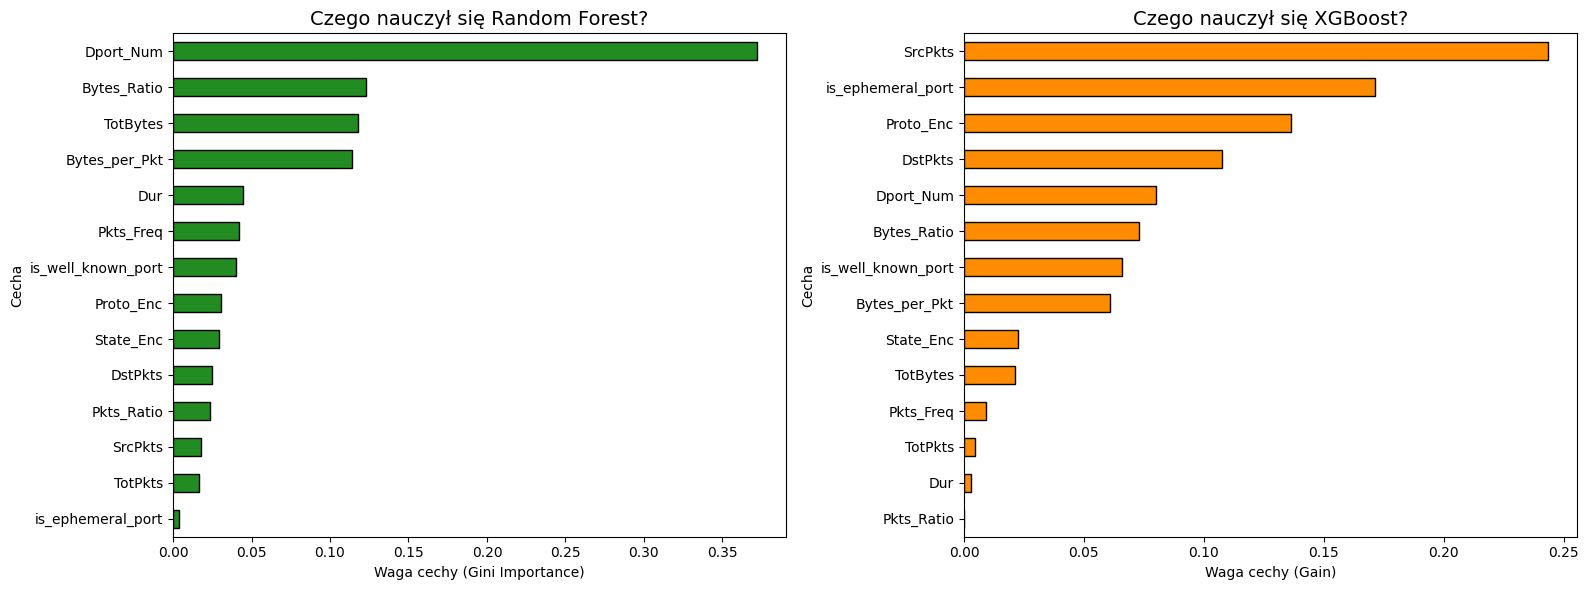


                 TABELA WAŻNOŚCI CECH (FEATURE IMPORTANCE) W %                  
CECHA                  | RANDOM FOREST   | XGBOOST         | ŚREDNIA Z MODELI
---------------------------------------------------------------------------
Dport_Num              |          37.19% |           8.03% |          22.61%
SrcPkts                |           1.76% |          24.33% |          13.04%
Bytes_Ratio            |          12.32% |           7.30% |           9.81%
is_ephemeral_port      |           0.39% |          17.12% |           8.76%
Bytes_per_Pkt          |          11.40% |           6.10% |           8.75%
Proto_Enc              |           3.05% |          13.64% |           8.34%
TotBytes               |          11.77% |           2.12% |           6.95%
DstPkts                |           2.48% |          10.77% |           6.62%
is_well_known_port     |           4.02% |           6.60% |           5.31%
State_Enc              |           2.94% |           2.27% |           

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import joblib

print("="*80)
print(">>> AKT 1: INICJALIZACJA SYSTEMÓW I WYTŁUMACZALNOŚĆ (XAI) <<<")
print("="*80)

# ==========================================
# 1. WCZYTANIE MODELI I ENKODERÓW
# ==========================================
model_dir = '../modele'
try:
    rf_model = joblib.load(os.path.join(model_dir, 'rf_production_model.joblib'))
    xgb_model = joblib.load(os.path.join(model_dir, 'xgb_production_model.joblib'))
    le_target = joblib.load(os.path.join(model_dir, 'label_encoder.joblib'))
    print("[+] Pomyślnie załadowano modele RF i XGBoost oraz Label Encoder.")
except Exception as e:
    print(f"[-] Błąd ładowania modeli: {e}. Upewnij się, że wykonałeś Krok 3 w poprzednich notatnikach!")

# ==========================================
# 2. ODTWORZENIE SŁOWNIKÓW I FUNKCJI 
# ==========================================
# Wczytujemy bazę treningową tylko po to, by odtworzyć słowniki protokołów i stanów
df_train_raw = pd.read_csv('../dane/gotowe_ml/honeypot_ml_ready.csv', low_memory=False)
known_protos = {p: i for i, p in enumerate(df_train_raw['Proto'].astype(str).unique())}
known_states = {s: i for i, s in enumerate(df_train_raw['State'].astype(str).unique())}

FEATURES = [
    'Dur', 'TotPkts', 'TotBytes', 'SrcPkts', 'DstPkts', 
    'Bytes_per_Pkt', 'Pkts_Freq', 'Pkts_Ratio', 'Bytes_Ratio', 
    'is_well_known_port', 'is_ephemeral_port',
    'Proto_Enc', 'State_Enc', 'Dport_Num'
]

def safe_encode(val, mapping_dict): return mapping_dict.get(str(val), -1)
def safe_port(p):
    try: return int(str(p), 16) if str(p).startswith('0x') else int(float(p))
    except: return 0

def prepare_future_logs(df_input):
    df = df_input.copy()
    for col in ['Dur', 'TotPkts', 'TotBytes', 'SrcPkts', 'DstPkts', 'SrcBytes', 'DstBytes']:
        df[col] = pd.to_numeric(df.get(col, 0), errors='coerce').fillna(0)
        
    df['Bytes_per_Pkt'] = df['TotBytes'] / (df['TotPkts'] + 1e-6)
    df['Pkts_Freq']     = df['TotPkts'] / (df['Dur'] + 1e-6)
    df['Pkts_Ratio']    = df['SrcPkts'] / (df['DstPkts'] + 1e-6)
    df['Bytes_Ratio']   = df.get('SrcBytes', 0) / (df.get('DstBytes', 0) + 1e-6)

    df['Dport_Num'] = df.get('Dport', 0).apply(safe_port)
    df['is_well_known_port'] = ((df['Dport_Num'] > 0) & (df['Dport_Num'] <= 1024)).astype(int)
    df['is_ephemeral_port'] = (df['Dport_Num'] >= 49152).astype(int)

    cols_to_log = ['Dur', 'TotPkts', 'TotBytes', 'SrcPkts', 'DstPkts', 
                   'Bytes_per_Pkt', 'Pkts_Freq', 'Pkts_Ratio', 'Bytes_Ratio']
    for col in cols_to_log:
        df[col] = np.log1p(df[col].clip(lower=0))

    df['Proto_Enc'] = df.get('Proto', '').astype(str).apply(lambda x: safe_encode(x, known_protos))
    df['State_Enc'] = df.get('State', '').astype(str).apply(lambda x: safe_encode(x, known_states))
    
    for f in FEATURES:
        if f not in df.columns: df[f] = 0
    return df[FEATURES].fillna(0)

# ==========================================
# 3. WIZUALIZACJA FEATURE IMPORTANCE
# ==========================================
print("\n[*] Generowanie wykresów Feature Importance...")
rf_importances = rf_model.feature_importances_
xgb_importances = xgb_model.feature_importances_

df_fi = pd.DataFrame({
    'Cecha': FEATURES,
    'Random Forest': rf_importances,
    'XGBoost': xgb_importances
}).set_index('Cecha')

# Wykresy
df_fi_sorted_rf = df_fi.sort_values(by='Random Forest', ascending=True)
df_fi_sorted_xgb = df_fi.sort_values(by='XGBoost', ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

df_fi_sorted_rf['Random Forest'].plot(kind='barh', ax=ax1, color='forestgreen', edgecolor='black')
ax1.set_title("Czego nauczył się Random Forest?", fontsize=14)
ax1.set_xlabel("Waga cechy (Gini Importance)")

df_fi_sorted_xgb['XGBoost'].plot(kind='barh', ax=ax2, color='darkorange', edgecolor='black')
ax2.set_title("Czego nauczył się XGBoost?", fontsize=14)
ax2.set_xlabel("Waga cechy (Gain)")

plt.tight_layout()
plt.savefig('../wykresy/11_feature_importance_comparison.png', dpi=300)
plt.show()

# ==========================================
# 4. TABELARYCZNE ZESTAWIENIE W PROCENTACH
# ==========================================
print("\n" + "="*80)
print(f"{'TABELA WAŻNOŚCI CECH (FEATURE IMPORTANCE) W %':^80}")
print("="*80)

# Obliczanie procentów (zabezpieczenie dzieleniem)
df_fi_pct = df_fi.copy()
df_fi_pct['RF %'] = (df_fi_pct['Random Forest'] / df_fi_pct['Random Forest'].sum()) * 100
df_fi_pct['XGB %'] = (df_fi_pct['XGBoost'] / df_fi_pct['XGBoost'].sum()) * 100
df_fi_pct['Średnia %'] = (df_fi_pct['RF %'] + df_fi_pct['XGB %']) / 2

# Sortowanie po średniej dla najlepszej czytelności
df_fi_pct = df_fi_pct.sort_values(by='Średnia %', ascending=False)

print(f"{'CECHA':<22} | {'RANDOM FOREST':<15} | {'XGBOOST':<15} | {'ŚREDNIA Z MODELI':<15}")
print("-" * 75)
for index, row in df_fi_pct.iterrows():
    print(f"{index:<22} | {row['RF %']:>14.2f}% | {row['XGB %']:>14.2f}% | {row['Średnia %']:>14.2f}%")
print("="*80 + "\n")

# Test A (Dryf Czasowy)

In [2]:
print("="*80)
print(">>> AKT 2: ARENA 'A' - DRYF CZASOWY (PRZYSZŁOŚĆ, TA SAMA LOKALIZACJA) <<<")
print("="*80)

CONFIDENCE_THRESHOLD = 0.75

# 1. Wczytanie logów Test A
files_A = glob.glob('../dane/testowe_A/*.csv')
dfs_A = [pd.read_csv(f, on_bad_lines="skip", low_memory=False) for f in files_A]
df_test_A = pd.concat(dfs_A, ignore_index=True) if dfs_A else pd.DataFrame()

if df_test_A.empty:
    print("[-] Brak danych w folderze 'testowe_A'!")
else:
    print(f"[*] Wczytano logi z przyszłości: {len(df_test_A)} rekordów. Rozpoczynam skanowanie...\n")
    X_A = prepare_future_logs(df_test_A)

    # Funkcja pomocnicza do generowania paszportu i statystyk
    def evaluate_model_on_arena(model, X_data, df_raw, model_name):
        probs = model.predict_proba(X_data)
        max_probs = np.max(probs, axis=1)
        pred_idx = np.argmax(probs, axis=1)
        
        # Odkodowanie klas (odporne na różne typy modeli)
        raw_classes = model.classes_[pred_idx] 
        if isinstance(raw_classes[0], str):
            predicted_classes = raw_classes
        else:
            predicted_classes = le_target.inverse_transform(raw_classes)

        decisions = np.where(max_probs >= CONFIDENCE_THRESHOLD, predicted_classes, 'UNKNOWN_Zero_Day')
        
        df_res = df_raw.copy()
        df_res['Decision'] = decisions
        df_res['Confidence'] = max_probs
        
        # Wymuszenie typów przed agregacją
        for col in ['Dur', 'TotPkts', 'Confidence']:
            if col in df_res.columns: df_res[col] = pd.to_numeric(df_res[col], errors='coerce')
        
        # Statystyki
        unknown_pct = (df_res['Decision'] == 'UNKNOWN_Zero_Day').mean() * 100
        print(f"\n[{model_name}] STATYSTYKA PEWNOŚCI:")
        print(f"    - Średnia pewność predykcji: {max_probs.mean():.4f}")
        print(f"    - Ruch odrzucony jako UNKNOWN (Zero-Day): {unknown_pct:.2f}%")
        
        # Funkcja do wyciągania dominanty (zwraca jeden, najczęstszy element)
        def get_mode(x): 
            m = pd.Series.mode(x)
            return m.iloc[0] if not m.empty else "N/A"

        # Agregacja Paszportu (Dport używa get_mode, tak jak chciałeś)
        report = df_res.groupby('Decision').agg({
            'Dur': 'median', 
            'TotPkts': 'median', 
            'State': get_mode, 
            'Dport': get_mode, 
            'Confidence': 'mean',
            'srcUdata': lambda x: x.dropna().iloc[0] if not x.dropna().empty else "[Brak Payloadu]"
        }).reset_index()
        
        # >>> TO JEST TA NAJWAŻNIEJSZA POPRAWKA (BEZPIECZNE MAPOWANIE) <<<
        class_sizes = df_res['Decision'].value_counts().to_dict()
        report['Liczność'] = report['Decision'].map(class_sizes)
        report = report.sort_values(by='Liczność', ascending=False)
        
        # Wydruk Paszportu (Oryginalna szerokość)
        print(f"\n{'DECYZJA MODELU':<35} | {'LICZNOŚĆ':<9} | {'PEWNOŚĆ':<8} | {'PORT':<6} | {'PKT':<4} | {'STATE':<6} | {'PRÓBKA Z PAYLOADU'}")
        print("-" * 125)
        for _, row in report.iterrows():
            p_raw = str(row['srcUdata']).replace('\n', ' ').replace('\r', ' ')
            p_clean = (p_raw[:25] + "...") if len(p_raw) > 28 else p_raw
            
            # Bezpieczne wyświetlanie portu (int dla 8889.0, str dla hexów)
            try: 
                p_port = str(int(float(row['Dport'])))
            except (ValueError, TypeError): 
                p_port = str(row['Dport'])
                
            label = f"!!! {row['Decision']} !!!" if row['Decision'] == 'UNKNOWN_Zero_Day' else str(row['Decision'])
            
            print(f"{label:<35} | {int(row['Liczność']):<9} | {row['Confidence']:<8.2f} | {p_port:<6} | {int(row['TotPkts']):<4} | {str(row['State']):<6} | {p_clean}")
        print("="*125)
        return unknown_pct

    unknown_rf_A = evaluate_model_on_arena(rf_model, X_A, df_test_A, "RANDOM FOREST")
    unknown_xgb_A = evaluate_model_on_arena(xgb_model, X_A, df_test_A, "XGBOOST")

>>> AKT 2: ARENA 'A' - DRYF CZASOWY (PRZYSZŁOŚĆ, TA SAMA LOKALIZACJA) <<<
[*] Wczytano logi z przyszłości: 55005 rekordów. Rozpoczynam skanowanie...


[RANDOM FOREST] STATYSTYKA PEWNOŚCI:
    - Średnia pewność predykcji: 0.8748
    - Ruch odrzucony jako UNKNOWN (Zero-Day): 18.70%

DECYZJA MODELU                      | LICZNOŚĆ  | PEWNOŚĆ  | PORT   | PKT  | STATE  | PRÓBKA Z PAYLOADU
-----------------------------------------------------------------------------------------------------------------------------
Mass TCP Port Scanning (L4)         | 42071     | 0.99     | 8889   | 3    | SR_RA  | s[6]=......
!!! UNKNOWN_Zero_Day !!!            | 10286     | 0.41     | 0x0100 | 1    | ECO    | s[102]=.../.SMBr......h.....
SIP Enumeration                     | 536       | 0.91     | 5060   | 1    | INT    | s[421]=OPTIONS sip:100@16...
NTP Enumeration                     | 267       | 0.90     | 123    | 1    | INT    | s[9]=...*.....
ISAKMP_VPN Brute Force              | 245       | 1.00     

# Test B (Dryf Przestrzenny)

In [3]:
print("="*80)
print(">>> AKT 3: ARENA 'B' - DRYF PRZESTRZENNY (INNY KONTYNENT / LOKALIZACJA) <<<")
print("="*80)

files_B = glob.glob('../dane/testowe_B/*.csv')
dfs_B = [pd.read_csv(f, on_bad_lines="skip", low_memory=False) for f in files_B]
df_test_B = pd.concat(dfs_B, ignore_index=True) if dfs_B else pd.DataFrame()

if df_test_B.empty:
    print("[-] Brak danych w folderze 'testowe_B'!")
else:
    print(f"[*] Wczytano logi z innej geolokalizacji: {len(df_test_B)} rekordów. Rozpoczynam skanowanie...\n")
    X_B = prepare_future_logs(df_test_B)

    unknown_rf_B = evaluate_model_on_arena(rf_model, X_B, df_test_B, "RANDOM FOREST")
    unknown_xgb_B = evaluate_model_on_arena(xgb_model, X_B, df_test_B, "XGBOOST")

>>> AKT 3: ARENA 'B' - DRYF PRZESTRZENNY (INNY KONTYNENT / LOKALIZACJA) <<<
[*] Wczytano logi z innej geolokalizacji: 61624 rekordów. Rozpoczynam skanowanie...


[RANDOM FOREST] STATYSTYKA PEWNOŚCI:
    - Średnia pewność predykcji: 0.9703
    - Ruch odrzucony jako UNKNOWN (Zero-Day): 4.46%

DECYZJA MODELU                      | LICZNOŚĆ  | PEWNOŚĆ  | PORT   | PKT  | STATE  | PRÓBKA Z PAYLOADU
-----------------------------------------------------------------------------------------------------------------------------
Mass TCP Port Scanning (L4)         | 56459     | 0.99     | 445    | 3    | S_RA   | s[6]=......
!!! UNKNOWN_Zero_Day !!!            | 2746      | 0.64     | 0x0300 | 2    | ECO    | s[36]=......................
SIP Enumeration                     | 706       | 0.91     | 5060   | 1    | INT    | s[373]=REGISTER sip:128.1...
LDAP Enumeration                    | 254       | 0.90     | 389    | 1    | INT    | s[53]=0....-...c....$.......
NTP Enumeration                    

# Ostateczne Podsumowanie Wizualne (Odrzuty OOD)

>>> AKT 4: WIZUALIZACJA ZDOLNOŚCI ODRZUCANIA ZAGROŻEŃ (OOD DETECTION) <<<
[+] Zapisano wykres podsumowujący odrzuty (Zero-Day Rejection).


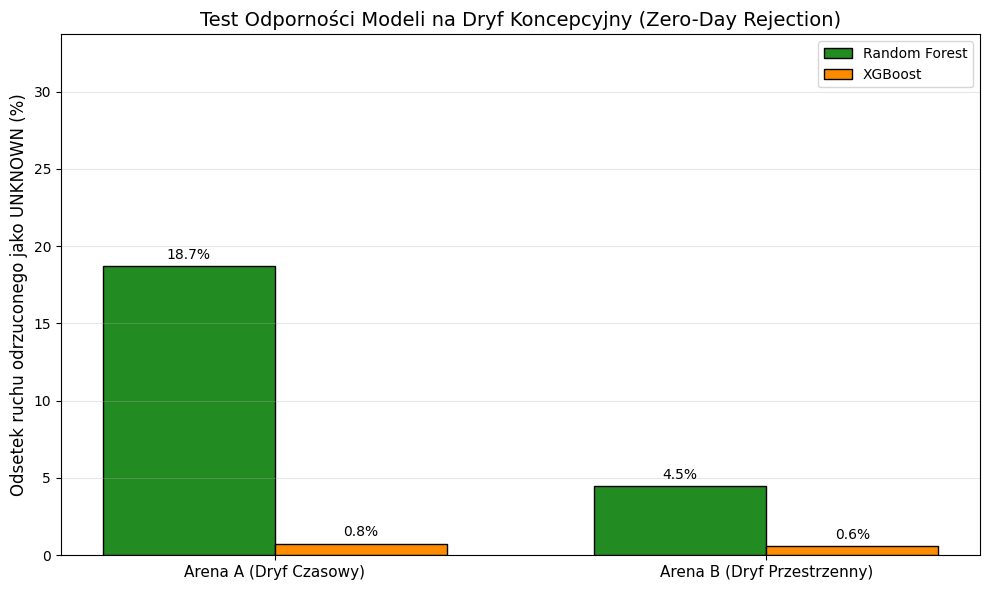

In [4]:
print("="*80)
print(">>> AKT 4: WIZUALIZACJA ZDOLNOŚCI ODRZUCANIA ZAGROŻEŃ (OOD DETECTION) <<<")
print("="*80)

try:
    labels = ['Arena A (Dryf Czasowy)', 'Arena B (Dryf Przestrzenny)']
    rf_rejects = [unknown_rf_A, unknown_rf_B]
    xgb_rejects = [unknown_xgb_A, unknown_xgb_B]

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, rf_rejects, width, label='Random Forest', color='forestgreen', edgecolor='black')
    rects2 = ax.bar(x + width/2, xgb_rejects, width, label='XGBoost', color='darkorange', edgecolor='black')

    ax.set_ylabel('Odsetek ruchu odrzuconego jako UNKNOWN (%)', fontsize=12)
    ax.set_title('Test Odporności Modeli na Dryf Koncepcyjny (Zero-Day Rejection)', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, max(max(rf_rejects), max(xgb_rejects)) + 15])

    # Dodanie etykiet nad słupkami
    ax.bar_label(rects1, padding=3, fmt='%.1f%%')
    ax.bar_label(rects2, padding=3, fmt='%.1f%%')

    plt.tight_layout()
    plt.savefig('../wykresy/12_zero_day_rejection_summary.png', dpi=300)
    print("[+] Zapisano wykres podsumowujący odrzuty (Zero-Day Rejection).")
    plt.show()
except NameError:
    print("[-] Uruchom najpierw komórki dla Areny A i Areny B, aby wygenerować wykres!")